In [ ]:
# Load Member 3's official "before" benchmark
perf_before = pd.read_csv(PERF_BEFORE_PATH)
print("Member 3's official baseline benchmark:")
perf_before

Member 3's official baseline benchmark:


,technique,total_time_sec,records_processed,throughput_rec_per_sec,memory_mb
0,Baseline (Single-threaded),5.029732,101212,20122.742171,0.0


In [ ]:
# Performance comparison: Before vs After
perf_after = pd.DataFrame([{
    'technique': f'Optimized (multiprocessing, {N_WORKERS} workers)',
    'total_time_sec': par_total_time,
    'records_processed': par_records,
    'throughput_rec_per_sec': par_throughput,
    'memory_mb': par_mem,
}])

perf_after.to_csv(os.path.join(OUT_DIR, 'performance_after.csv'), index=False)

# perf_before was loaded from Member 3's performance_before.csv in Step 1
perf_compare = pd.concat([perf_before, perf_after], ignore_index=True)
perf_compare['speedup_x'] = perf_compare['total_time_sec'].iloc[0] / perf_compare['total_time_sec']
perf_compare.to_csv(os.path.join(OUT_DIR, 'performance_comparison.csv'), index=False)
perf_compare

,technique,total_time_sec,records_processed,throughput_rec_per_sec,memory_mb,speedup_x
0,Baseline (Single-threaded),5.029732,101212,20122.742171,0.000000,1.000000
1,"Optimized (multiprocessing, 2 workers)",1.457575,101212,69438.607068,96.347656,3.450753


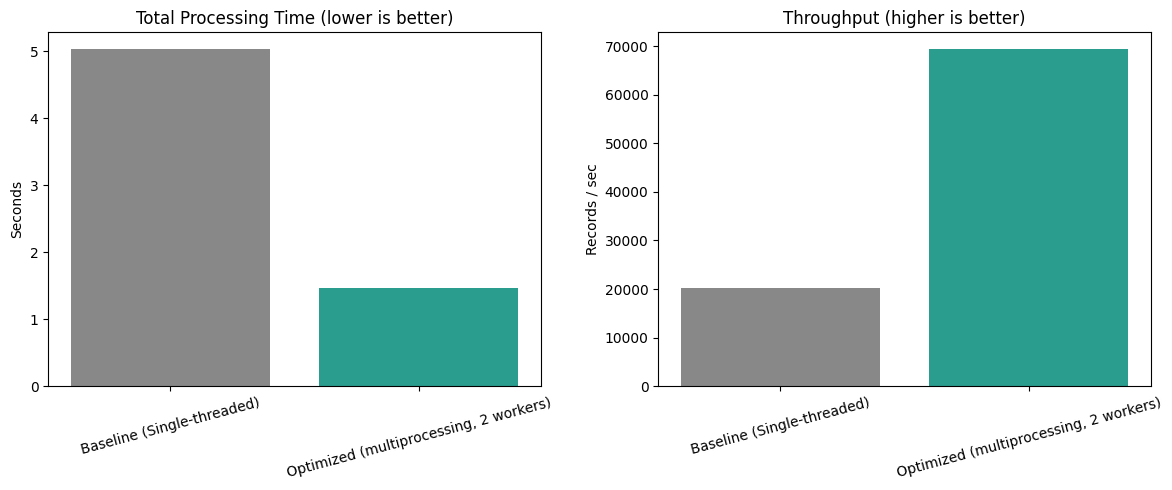

Speedup: 3.45x  (using 2 worker process(es) on this machine)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#888888', '#2a9d8f']

axes[0].bar(perf_compare['technique'], perf_compare['total_time_sec'], color=colors)
axes[0].set_title('Total Processing Time (lower is better)')
axes[0].set_ylabel('Seconds')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(perf_compare['technique'], perf_compare['throughput_rec_per_sec'], color=colors)
axes[1].set_title('Throughput (higher is better)')
axes[1].set_ylabel('Records / sec')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'performance_comparison.png'), dpi=150)
plt.show()

print(f"Speedup: {perf_compare['speedup_x'].iloc[1]:.2f}x  "
      f"(using {N_WORKERS} worker process(es) on this machine)")

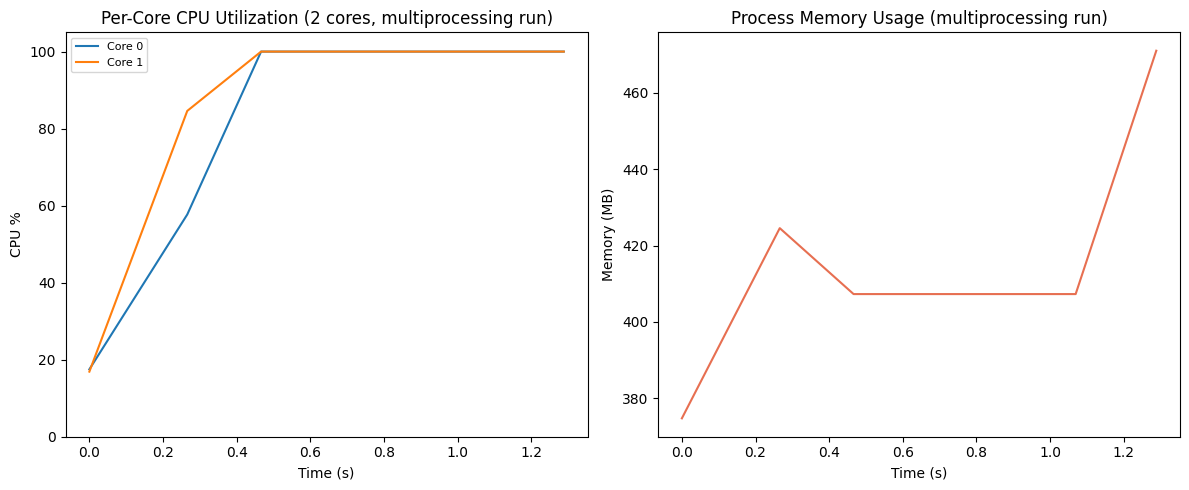

In [ ]:
# Hardware utilization profile during the optimized run
cpu_arr = np.array(monitor_log['cpu_percpu'])  # shape: (samples, cores)
t_arr = np.array(monitor_log['t'])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for core_idx in range(cpu_arr.shape[1]):
    axes[0].plot(t_arr, cpu_arr[:, core_idx], label=f'Core {core_idx}')
axes[0].set_title(f'Per-Core CPU Utilization ({N_WORKERS} cores, multiprocessing run)')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('CPU %')
axes[0].set_ylim(0, 105)
axes[0].legend(fontsize=8)

axes[1].plot(t_arr, monitor_log['mem_mb'], color='#e76f51')
axes[1].set_title('Process Memory Usage (multiprocessing run)')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Memory (MB)')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'hardware_utilization.png'), dpi=150)
plt.show()